## Projeto Final

### Estudo de caso:  Short-term fasting effect on skeletal muscle: time course

Descrição do dataset:
Análise de biópsias musculares esqueléticas recolhidas em 1,5; 4; 10 e 24 horas após a refeição em homens jovens e saudáveis submetidos a um jejum de 24 horas. Os resultados fornecem uma compreensão sobre os mecanismos moleculares subjacentes à adaptação metabólica ao jejum em seres humanos saudáveis. O objetivo é estabelecer uma relação entre a expressão gênica e o tempo de jejum.
O dataset apresenta uma coleção de genes, cerca de 48107 de 48 amostras. Cada amostra é caracterizada no metadaset com base em 4 variáveis: amostra (sample), individuo (individual), tempo (time) e descrição (description).  

Ficheros usados :
- *gds5473.csv* - file with gene expression data ( Gene-> ILMN...)
- *meta-gds5473.csv* - clinical variables for each sample (GSM..) 


In [1]:

import pandas as pd
import numpy as np
from sklearn import *
from sklearn.decomposition import PCA

%matplotlib inline
import matplotlib.pyplot as plt

## Etapa 1

### Leitura dos dados e dos metadados


In [2]:
# Opening the dataset with pandas
data = pd.read_csv("gds5473.csv", sep=',', index_col = 0)
# Opening the metadata
meta = pd.read_csv("meta-gds5473.csv", sep = ",", index_col = 0)


In [3]:
data.head()

,GSM1348553,GSM1348554,GSM1348555,GSM1348556,GSM1348557,GSM1348558,GSM1348559,GSM1348560,GSM1348561,GSM1348562,...,GSM1348591,GSM1348592,GSM1348593,GSM1348594,GSM1348595,GSM1348596,GSM1348597,GSM1348598,GSM1348599,GSM1348600
ILMN_1343048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ILMN_1343049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ILMN_1343050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ILMN_1343052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ILMN_1343059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
meta.head()

,sample,individual,time,description
GSM1348553,GSM1348553,subject 1,hour 1.5,"Value for GSM1348553: Subject 1 - 1,5h post-me..."
GSM1348554,GSM1348554,subject 1,hour 4,Value for GSM1348554: Subject 1 - 4h post-meal...
GSM1348555,GSM1348555,subject 1,hour 10,Value for GSM1348555: Subject 1 - 10h post-mea...
GSM1348556,GSM1348556,subject 1,hour 24,Value for GSM1348556: Subject 1 - 24h post-mea...
GSM1348557,GSM1348557,subject 2,hour 1.5,"Value for GSM1348557: Subject 2 - 1,5h post-me..."


In [5]:
print(data.values.shape)
print(meta.values.shape)

(48107, 48)
(48, 4)


Existem 48107 genes de 48 amostras diferentes no dataset. No meta-dataset estão presentes 48 amostras e 4 colunas com os atributos sample, individual, time e description. No caso do data, como irá ser feita uma aplicacao de machine learning e os objetos de estudo serão os genes, é necessários estes se encontrarem nas colunas. Consequentemente, realizou-se a transposta no dataset.

In [6]:
data_all = data.transpose()
data_all.head()

,ILMN_1343048,ILMN_1343049,ILMN_1343050,ILMN_1343052,ILMN_1343059,ILMN_1343061,ILMN_1343062,ILMN_1343063,ILMN_1343064,ILMN_1343291,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
GSM1348553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.9,...,7.3,7.3,7.2,7.3,7.6,7.0,7.3,7.3,7.2,7.3
GSM1348554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.6,...,7.1,7.1,7.3,7.2,7.5,7.3,7.2,7.5,7.3,7.2
GSM1348555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.1,...,7.2,7.5,7.4,7.1,7.5,7.2,7.2,7.4,7.2,7.4
GSM1348556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.7,...,7.2,7.4,7.2,7.2,7.4,7.1,7.3,7.5,7.4,7.3
GSM1348557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.1,...,7.1,7.3,7.2,7.4,7.6,7.3,7.1,7.4,7.3,7.3


### Exploração dos dados

In [7]:
data_all.describe() ## transposto - por genes

,ILMN_1343048,ILMN_1343049,ILMN_1343050,ILMN_1343052,ILMN_1343059,ILMN_1343061,ILMN_1343062,ILMN_1343063,ILMN_1343064,ILMN_1343291,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.047917,...,7.247917,7.322917,7.293750,7.237500,7.460417,7.241667,7.225000,7.360417,7.220833,7.287500
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.245807,...,0.107168,0.127562,0.113749,0.108422,0.128394,0.104847,0.106191,0.116216,0.100970,0.098121
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.300000,...,7.000000,7.000000,7.100000,6.900000,7.200000,7.000000,7.000000,7.200000,7.000000,7.100000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.900000,...,7.200000,7.200000,7.200000,7.200000,7.400000,7.200000,7.200000,7.300000,7.200000,7.200000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.100000,...,7.250000,7.300000,7.300000,7.200000,7.500000,7.200000,7.200000,7.300000,7.200000,7.300000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.200000,...,7.300000,7.400000,7.400000,7.300000,7.500000,7.300000,7.300000,7.500000,7.300000,7.400000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.500000,...,7.500000,7.600000,7.500000,7.500000,7.800000,7.500000,7.500000,7.600000,7.500000,7.500000


In [8]:
data.describe() ## por amostras (pacientes)

,GSM1348553,GSM1348554,GSM1348555,GSM1348556,GSM1348557,GSM1348558,GSM1348559,GSM1348560,GSM1348561,GSM1348562,...,GSM1348591,GSM1348592,GSM1348593,GSM1348594,GSM1348595,GSM1348596,GSM1348597,GSM1348598,GSM1348599,GSM1348600
count,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,...,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000,47323.000000
mean,7.715842,7.715842,7.715842,7.715842,7.715844,7.715842,7.715842,7.715842,7.715844,7.715842,...,7.715842,7.715842,7.715842,7.715842,7.715844,7.715844,7.715842,7.715844,7.715842,7.715842
std,1.063854,1.063854,1.063854,1.063854,1.063854,1.063854,1.063854,1.063854,1.063853,1.063854,...,1.063854,1.063854,1.063854,1.063854,1.063854,1.063853,1.063854,1.063853,1.063854,1.063854
min,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,...,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000,6.800000
25%,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,...,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000,7.200000
50%,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,...,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000,7.400000
75%,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,...,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000,7.600000
max,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,...,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000,15.300000


In [9]:
# tipo de atributos
meta.dtypes

sample         object
individual     object
time           object
description    object
dtype: object

In [10]:
meta.describe(include = "all")

,sample,individual,time,description
count,48,48,48,48
unique,48,12,4,48
top,GSM1348553,subject 1,hour 1.5,"Value for GSM1348553: Subject 1 - 1,5h post-me..."
freq,1,4,12,1


In [11]:
data_all.isnull().sum().sum() ## missing values no dataset

37632

In [12]:
data_all.isnull().sum()

ILMN_1343048    48
ILMN_1343049    48
ILMN_1343050    48
ILMN_1343052    48
ILMN_1343059    48
                ..
ILMN_3311170     0
ILMN_3311175     0
ILMN_3311180     0
ILMN_3311185     0
ILMN_3311190     0
Length: 48107, dtype: int64

In [13]:
meta.isnull().sum().sum() ## missing values no metadaset

0

### Tratamento de missing values

Através da análise de missing values, foi possível inferir que existem 37632 valores nulos no dataset 'gds5473.csv'.
Desta forma, considerou-se que o tratamento mais adequado seria proceder à remoção dos mesmos.


In [14]:
data_all.dropna(axis="columns", inplace=True)             
data.dropna(axis=0,inplace=True )
data_all.shape

(48, 47323)

Com o tratamento dos valores nulos, restam 47323 genes a serem analisados

### Seleção de variáveis

Analisando todas as variáveis do metadataset,chegou-se à conclusão que a única relevante é o tempo de jejum até à recolha da amostra (time).
Com efeito, procedeu-se à remoção das restantes variáveis.

In [15]:
meta.drop(['sample', 'description', 'individual'], axis=1, inplace=True)
meta.head()

,time
GSM1348553,hour 1.5
GSM1348554,hour 4
GSM1348555,hour 10
GSM1348556,hour 24
GSM1348557,hour 1.5


### Exploração Gráfica

<Axes: >

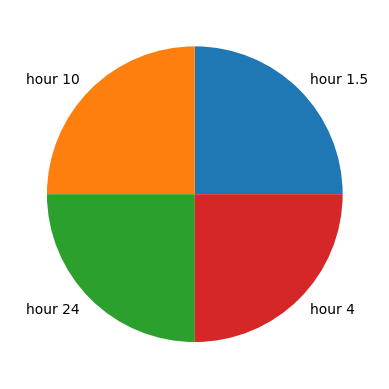

In [16]:
meta.groupby("time").size().plot.pie()

In [17]:
meta.groupby("time").size() 

time
hour 1.5    12
hour 10     12
hour 24     12
hour 4      12
dtype: int64

Através da exploração gráfica, foi possível inferir que o target está balanceado, possuindo para cada classe 12 amostras analisadas.

### Análise da variabilidade

 Variabilidade média dos níveis de expressão génica entre as amostras para todos os genes considerados.

In [18]:
input_data = data_all.values 

print(input_data.shape)

(48, 47323)


In [19]:

variances = input_data.var(axis = 0) # calculate the variance for each gene

print(variances.shape)

medvar = variances.mean()
medvar

(47323,)


0.025840169846351436

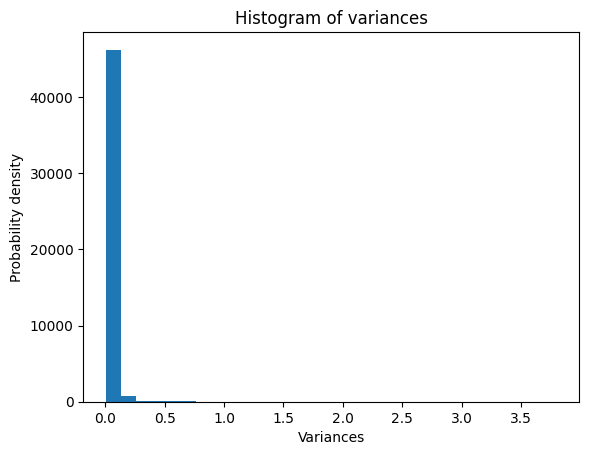

In [20]:
plt.hist(variances, bins = 30)
plt.xlabel('Variances')
plt.ylabel('Probability density')
plt.title(r'Histogram of variances')
plt.show()

A partir da análise do gráfico, os níveis de expressão de genes tendem a ser relativamente estáveis ou consistentes entre as amostras, pelo menos em termos de variabilidade.

In [21]:
# variability filters (flat patterns)
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold= medvar*3)
input_filt = sel.fit_transform(input_data)
input_filt.shape

(48, 2371)

### Expressão Diferencial de genes

Foi elaborada uma análise de seleção de características usando o método ANOVA (ou teste t) para selecionar genes diferencialmente expressos. 
 Os genes que apresentam diferenças estatisticamente significativas são os que são destacados como genes diferencialmente expressos.
 O p-value para a rejeição da hipótese nula foi de 0.01.

In [22]:
from sklearn.feature_selection import SelectPercentile, f_classif

# fclassif - ANOVA or t-test (in this case we will select t-test since mdr has only two variables)
# We are selecting genes with the lowest p-value (10% of genes with the lowes value)
selector = SelectPercentile(f_classif, percentile=10)

output_time = meta.values[:,0]

selector.fit_transform(data_all, output_time)
genes_dif = np.where(selector.pvalues_ <0.01)

print(data_all.columns[genes_dif])

Index(['ILMN_1651278', 'ILMN_1651285', 'ILMN_1651628', 'ILMN_1651767',
       'ILMN_1651964', 'ILMN_1652082', 'ILMN_1652085', 'ILMN_1652246',
       'ILMN_1652407', 'ILMN_1652549',
       ...
       'ILMN_3307782', 'ILMN_3307791', 'ILMN_3307892', 'ILMN_3307906',
       'ILMN_3307958', 'ILMN_3309494', 'ILMN_3310118', 'ILMN_3310226',
       'ILMN_3310835', 'ILMN_3310840'],
      dtype='object', length=2047)


## Etapa 2

#  Unsupervised machine learning

#### Pré-Processamento dos dados

In [23]:
data_scale = preprocessing.scale(input_data)
print("Average: ", data_scale.mean())
print("Standard Deviation: ", data_scale.std())
input_dif = data_scale[:,genes_dif[0]]

Average:  -1.6160869582580446e-16
Standard Deviation:  1.0000000000000002


### PCA

In [24]:
pca = PCA(n_components=0.9)
X_r = pca.fit(data_scale).transform(data_scale)

print('Explained Variance: %s'% str(pca.explained_variance_ratio_))
pca.explained_variance_ratio_.sum()

Explained Variance: [0.0600652  0.05692305 0.03827444 0.033794   0.02967008 0.02914113
 0.02558613 0.0249199  0.02346026 0.02336347 0.02285573 0.02241609
 0.02133673 0.02128118 0.02033127 0.02020278 0.02007006 0.01969584
 0.01927423 0.01876734 0.01852937 0.01837052 0.01816186 0.01802457
 0.01789171 0.01778614 0.01763206 0.01741641 0.01722435 0.01716251
 0.01708501 0.01682934 0.01679698 0.01667714 0.01647834 0.01629903
 0.01618404 0.01601692 0.01589857 0.01587628 0.0157441 ]


0.9095141516999561

In [25]:
X_r.shape[1]

41

41 componentes explicam 90% da variabilidade.

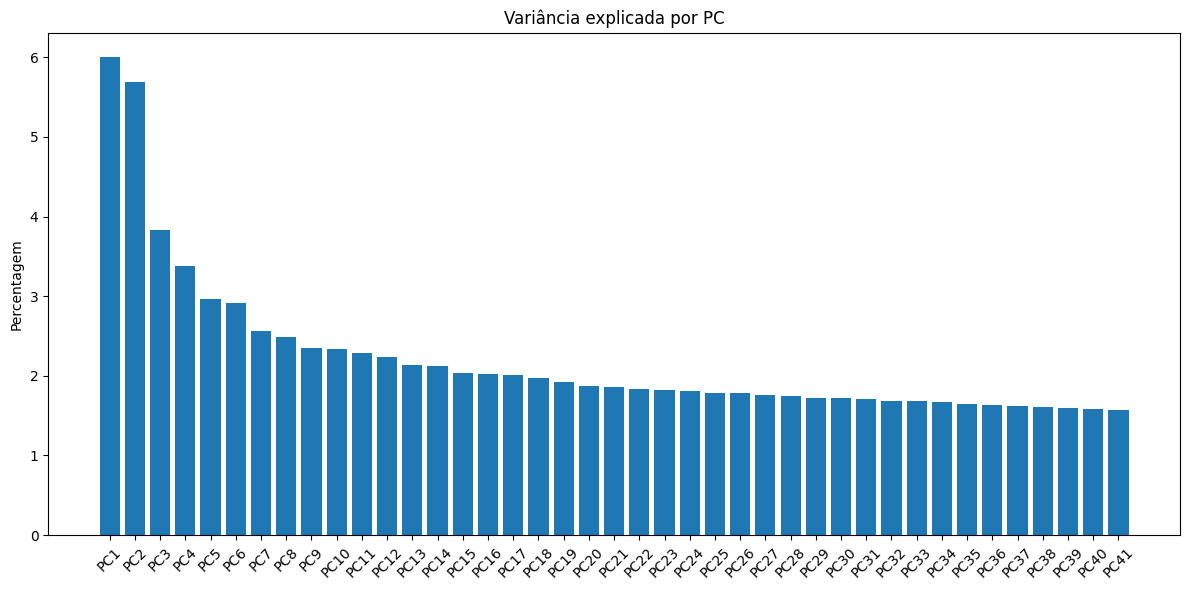

In [26]:
n = 41
plt.figure(figsize=(12, 6))
plt.bar(range(n), pca.explained_variance_ratio_*100)
plt.xticks(range(n), ['PC'+str(i) for i in range(1,n+1)],rotation=45)
plt.title("Variância explicada por PC")
plt.ylabel("Percentagem")
plt.tight_layout()
plt.show()

Através da análise as proporções da variância total explicadas por cada um dos componentes principais obtidos após a aplicação da Análise de Componentes Principais (PCA) nos dados, não foi possível realizar a redução de dimensionalidade, visto que cada componente retém percentagens da variância total muito baixas.

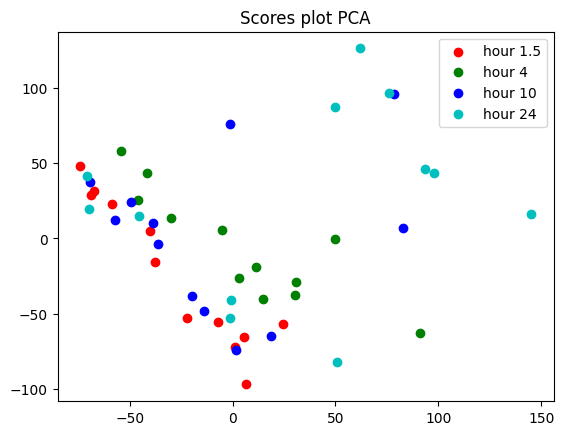

In [27]:
plt.figure()
for c, name in zip("rgbc", ['hour 1.5', 'hour 4' ,'hour 10','hour 24']):
    plt.scatter(X_r[meta['time'] == name, 0], X_r[meta['time'] == name, 1], c=c, label=name)
plt.legend()
plt.title('Scores plot PCA')
plt.show()

### Hierarchical clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering

hclust = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="complete")
hclust.fit(data_scale)

AgglomerativeClustering(linkage='complete', metric='euclidean', n_clusters=4)

In [29]:
res_hc = hclust.labels_
pd.crosstab (meta["time"], res_hc)


col_0,0,1,2,3
time,,,,
hour 1.5,4,0,7,1
hour 10,3,3,6,0
hour 24,3,6,3,0
hour 4,6,0,6,0


In [30]:
## explicar q nao se permite tirar conclusoes dos resultados

### K-means clustering

In [31]:
from sklearn.cluster import KMeans
k=4
kmeans = KMeans(n_clusters=k, max_iter = 1000, n_init = 10)
kmeans.fit(data_scale)
labels = kmeans.labels_
centroids= kmeans.cluster_centers_
pd.crosstab (labels,meta["time"],rownames=['clusters'])

time,hour 1.5,hour 10,hour 24,hour 4
clusters,,,,
0,1,2,1,6
1,3,0,2,0
2,8,7,3,6
3,0,3,6,0


Os resultados obtidos sem filtro  não permitem tirar grandes conclusões. Aplicando agora o filtro da Expressão des genes diferenciais:

**Tendo em conta a Expressão de Gene Diferencial**

In [32]:
pca = PCA(n_components=41)
X_r = pca.fit(input_dif).transform(input_dif)

print('Explained Variance: %s'% str(pca.explained_variance_ratio_))
pca.explained_variance_ratio_.sum()

Explained Variance: [0.28182264 0.14913318 0.04463469 0.03989197 0.03447119 0.02560766
 0.02444201 0.02391823 0.02091768 0.01868887 0.01735184 0.01657313
 0.01588103 0.01453841 0.01311724 0.01263246 0.01209371 0.01130122
 0.01122964 0.01070109 0.01029924 0.00997914 0.00982635 0.0094568
 0.00932388 0.00894005 0.00878706 0.0085623  0.00820831 0.00784634
 0.00782363 0.0076679  0.0074187  0.00739719 0.00721519 0.0070389
 0.00692937 0.00661103 0.00643081 0.00632982 0.00604361]


0.9670835026962648

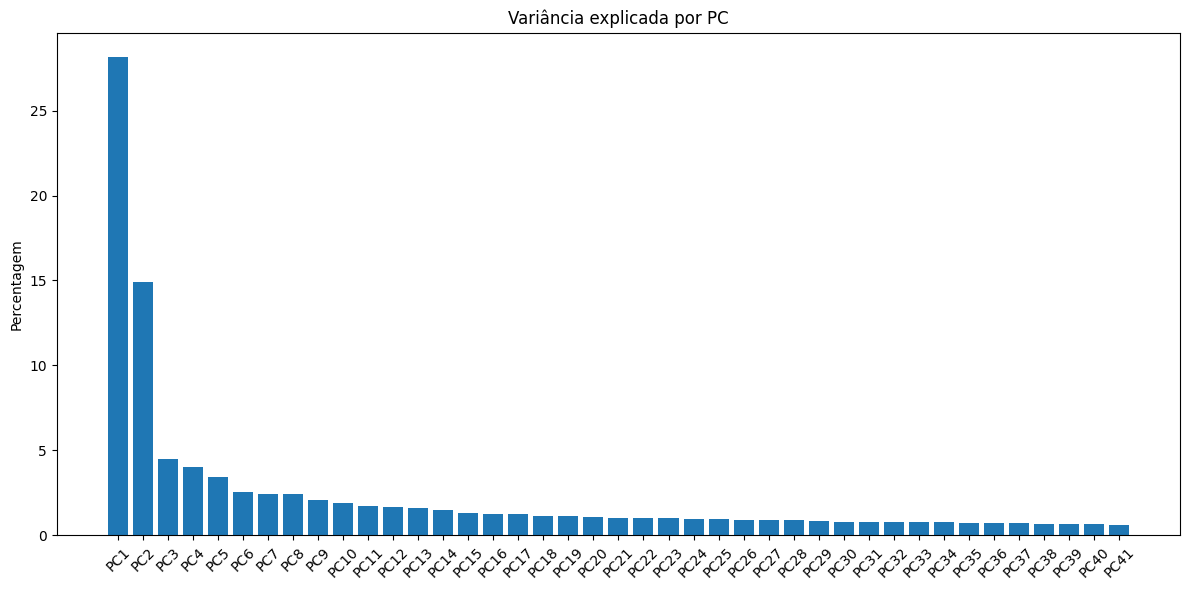

In [33]:
n = 41
plt.figure(figsize=(12, 6))
plt.bar(range(n), pca.explained_variance_ratio_*100)
plt.xticks(range(n), ['PC'+str(i) for i in range(1,n+1)],rotation=45)
plt.title("Variância explicada por PC")
plt.ylabel("Percentagem")
plt.tight_layout()
plt.show()


Após a aplicação do filtro, os resultados melhoraram significativamente. Agora, os 2 primeiros componentes PC1 e PC2 explicam  cerca
de 43% da variabilidade.

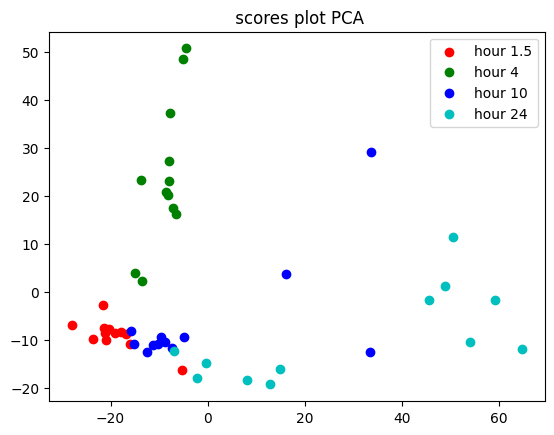

In [34]:
plt.figure()
for c, name in zip("rgbc", ['hour 1.5', 'hour 4' ,'hour 10','hour 24']):
    plt.scatter(X_r[output_time == name, 0], X_r[output_time == name, 1], c=c, label=name)
plt.legend()
plt.title(' scores plot PCA')
plt.show()

### Hierarchical clustering

In [35]:
from sklearn.cluster import AgglomerativeClustering

hclust = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="complete")
hclust.fit(input_dif)

AgglomerativeClustering(linkage='complete', metric='euclidean', n_clusters=4)

In [36]:
res_hc = hclust.labels_
pd.crosstab (meta["time"], res_hc)

col_0,0,1,2,3
time,,,,
hour 1.5,0,0,12,0
hour 10,1,0,9,2
hour 24,9,0,3,0
hour 4,0,10,2,0


In [37]:
Z = linkage(input_dif, method='single', metric='euclidean')    
Z[:10]

NameError: name 'linkage' is not defined

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
plt.figure(figsize=(25, 10))   # Creates a generic figure
dendrogram(                             # Creates the dendogram
            Z,
            labels=np.array(output_time),    #  select the labels
            leaf_rotation=90.,  # rotates the x-axis labels
            leaf_font_size=8,  # font size for the x-axis labels
)

plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('distance')

# Assignment of colors to labels: 'a' is red, 'b' is green, etc. rgbc 'hour 1.5', 'hour 4' ,'hour 10','hour 24'
label_colors = {'hour 1.5': 'r', 'hour 4': 'g', 'hour 10': 'b', 'hour 24':'c' }
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    lbl.set_color(label_colors[lbl.get_text()])
plt.show()

### K-means clustering

In [ ]:
from sklearn.cluster import KMeans
k=4
kmeans = KMeans(n_clusters=k, max_iter = 1000, n_init = 10)
kmeans.fit(input_dif)
labels = kmeans.labels_
centroids= kmeans.cluster_centers_
pd.crosstab (labels,meta["time"],rownames=['clusters'])

In [ ]:
for i in range(k):
    ds = input_dif[np.where(labels==i)]
    plt.plot(ds[:,0],ds[:,1],'o')
    lines = plt.plot(centroids[i,0],centroids[i,1],'kx')
    
    plt.setp(lines,ms=20.0)    # x size 
    plt.setp(lines,mew=2.0)    # line width
    
plt.show()

In [ ]:
# comentar resultados

## Etapa 3

# Supervised Machine Learning

Let's consider the MDR variable as the output variable. For attributes, we will only include the genes that are identified as differentially expressed above. Omics datasets often have a high dimensionality, meaning they contain many more features (genes) than samples. Including all genes in the analysis can lead to a worse performance of machine learning algorithms due to the large number of features. Focusing on differentially expressed genes helps reduce the dimensionality and can improve model performance.

In [ ]:
input_dif = data_scale[:,genes_dif[0]]

print(input_dif.shape)

Para a aplicação de aprendizagem supervisionada é necessário dividir os dados em dados para treino e para teste. Desta forma, foi feita a partição com holdout.

### Split Data - holdout

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
target = meta['time']
train_in, test_in, train_out, test_out = train_test_split(input_dif, target, test_size=1/3, random_state=1)
print(train_in.shape)
print(test_in.shape)

Posteriormente, foram utilizados 3 modelos : K-Nearest Neighbors (KNN), Decision Trees (DT) e Naive Bayes

## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(train_in, train_out)
preds = knn.predict(test_in)

print("Predicted Values: ", preds)
print("Real Values: " , test_out)
print("Correct Predition Percentage: ( Accuracy) ", (preds == test_out).sum()/len(preds) )

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score,ConfusionMatrixDisplay

In [ ]:
# Matriz de Confusão
knn_cm = ConfusionMatrixDisplay.from_predictions(test_out, preds, display_labels=knn.classes_, cmap='Blues')
knn_cm

Explicar que a avalicao nao depende so da acuraccy , por isso procedemos a outra metricas de avaliacao, e explicar porque é que estas sao importantes ( definicao) -(AEC esta o q faz cada uma e pk e que e importante) .
Choose Recall if the idea of false positives is far
better than false negatives, in other words, if th 
occurrence of false negativess s
unaccept ed/intolera   ble
• Choose precision if you want to be more confi ent
of your true posi

-> Precision = TP/(TP+FP)->  Recall = TP/(TP+FN)tives

In [ ]:
# Métricas de Avaliação 
print('Precision: %0.2f' % precision_score(test_out,preds, average='weighted'))
print('Recall: %0.2f' % recall_score(test_out,preds, average='weighted'))

## Árvores de Decisão (DT)

In [ ]:
from sklearn import tree

tree_model = tree.DecisionTreeClassifier()
tree_model = tree_model.fit(train_in, train_out)
preds_tree = tree_model.predict(test_in)

print("Correct Predition Percentage: ", (preds_tree == test_out).sum()/len(preds_tree) )

In [ ]:
# Matriz de Confusão
tree_cm = ConfusionMatrixDisplay.from_predictions(test_out, preds_tree, display_labels=tree_model.classes_, cmap='Blues')
tree_cm

In [ ]:
# Métricas de Avaliação
print('Precisão: %0.2f' % precision_score(test_out,preds_tree, average='weighted'))
print('Sensibilidade: %0.2f' % recall_score(test_out,preds_tree, average='weighted'))


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(train_in, train_out )
preds_gnb = gnb_model.predict(test_in)

print("Correct Predition Percentage: ", (preds_gnb== test_out).sum()/len(preds_gnb) )


In [ ]:
naive_cm = ConfusionMatrixDisplay.from_predictions(test_out, preds_gnb, display_labels=gnb_model.classes_, cmap='Blues')
naive_cm

In [ ]:
# Métricas de avaliação
print('Precision: %0.2f' % precision_score(test_out, preds_gnb, average='weighted'))
print('Recall: %0.2f' % recall_score(test_out, preds_gnb, average='weighted'))

Tendo em conta os resultados obtidos, o modelo quer resultou prever fazer uma previsão com melhor desempenho, sensibilidade e desempenho foi o modelo KNN, obtendo-se 75%, 84% e 75% de accuracy, precisão e sensibilidade, respetivamente.

Para melhorar a qualidade do modelo , foi testada outra técnica de partição de dados, o cross- validation.

### Cross- Validation

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores_svm_cv = cross_val_score(estimator=knn, X=input_dif, y=target, cv = 5)

print('Accuracy values:', scores_svm_cv)
print('Mean accuracy: %0.2f' % scores_svm_cv.mean())


In [ ]:
scores_svm_cv = cross_val_score(estimator=tree_model, X=input_dif, y=target, cv = 5)

print('Accuracy values:', scores_svm_cv)
print('Mean accuracy: %0.2f' % scores_svm_cv.mean())


In [ ]:
scores_svm_cv = cross_val_score(estimator=gnb_model, X=input_dif, y=target, cv = 5)

print('Accuracy values:', scores_svm_cv)
print('Mean accuracy: %0.2f' % scores_svm_cv.mean())


Com a técnica de cross-validation obteve-se um melhor desempenho nas métricas de avaliação. Com efeito, a melhor previsão foi feita com o modelo KNN utilizando a técnica de cross-validation para a divisão de treino e teste. Obteve-se 85% de accuracy.